# **Predicting Credit Default Risk from Application and Transaction Records**

*by Lin Zhu 2025-11*

## Business Context:

Credit score cards are a common risk control method in the financial industry.  
It uses personal information and data submitted by credit card applicants to predict the probability of future defaults and credit card borrowings.  
The bank is able to decide whether to issue a credit card to the applicant.

---

Credit score cards are a common risk control method in the financial industry. It uses personal information and data submitted by credit card applicants to predict the probability of future defaults and credit card borrowings. The bank is able to decide whether to issue a credit card to the applicant. Credit scores can objectively quantify the magnitude of risk.

Generally speaking, credit score cards are based on historical data. Once encountering large economic fluctuations. Past models may lose their original predictive power. Logistic model is a common method for credit scoring. Because Logistic is suitable for binary classification tasks and can calculate the coefficients of each feature. In order to facilitate understanding and operation, the score card will multiply the logistic regression coefficient by a certain value (such as 100) and round it.

At present, with the development of machine learning algorithms. More predictive methods such as Boosting, Random Forest, and Support Vector Machines have been introduced into credit card scoring. However, these methods often do not have good transparency. It may be difficult to provide customers and regulators with a reason for rejection or acceptance.


In [ ]:
import pandas as pd
applications = pd.read_csv("application_record.csv", encoding = 'utf-8')
record = pd.read_csv("credit_record.csv", encoding = 'utf-8')

### Application Data

In [ ]:
applications.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474.0,-1134.0,1.0,0.0,0.0,0.0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0


In [ ]:
applications.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406230 entries, 0 to 406229
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   406230 non-null  int64  
 1   CODE_GENDER          406230 non-null  object 
 2   FLAG_OWN_CAR         406230 non-null  object 
 3   FLAG_OWN_REALTY      406230 non-null  object 
 4   CNT_CHILDREN         406230 non-null  int64  
 5   AMT_INCOME_TOTAL     406230 non-null  float64
 6   NAME_INCOME_TYPE     406230 non-null  object 
 7   NAME_EDUCATION_TYPE  406230 non-null  object 
 8   NAME_FAMILY_STATUS   406229 non-null  object 
 9   NAME_HOUSING_TYPE    406229 non-null  object 
 10  DAYS_BIRTH           406229 non-null  float64
 11  DAYS_EMPLOYED        406229 non-null  float64
 12  FLAG_MOBIL           406229 non-null  float64
 13  FLAG_WORK_PHONE      406229 non-null  float64
 14  FLAG_PHONE           406229 non-null  float64
 15  FLAG_EMAIL       

In [ ]:
applications.shape

(406230, 18)

### Record Data

In [ ]:
record.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [ ]:
record.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [ ]:
record.shape

(1048575, 3)

### column names to lower case

In [ ]:
applications.columns= applications.columns.str.lower()

In [ ]:
record.columns= record.columns.str.lower()

### Missing value

In [ ]:
applications.isna().sum()

,0
id,0
code_gender,0
flag_own_car,0
flag_own_realty,0
cnt_children,0
amt_income_total,0
name_income_type,0
name_education_type,0
name_family_status,1
name_housing_type,1


In [ ]:
record.isna().sum()

,0
id,0
months_balance,0
status,0


### Fill NAs

In [ ]:
# Fill missing values
applications['occupation_type'].fillna(value='Other', inplace=True)

/tmp/ipython-input-88991722.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  applications['occupation_type'].fillna(value='Other', inplace=True)


### Deduplicate

In [ ]:
import numpy as np
print(f'Duplicates in applications df: {applications.iloc[:,1:].duplicated().sum()}, ({np.round(100*applications.iloc[:,1:].duplicated().sum()/len(applications),1)}%)')
print('')
print(f'Duplicates in record df: {record.duplicated().sum()}, ({np.round(100*record.duplicated().sum()/len(record),1)}%)')

Duplicates in applications df: 321140, (79.1%)

Duplicates in record df: 0, (0.0%)


In [ ]:
applications.shape

(406230, 18)

In [ ]:
applications.head()

,id,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,name_income_type,name_education_type,name_family_status,name_housing_type,days_birth,days_employed,flag_mobil,flag_work_phone,flag_phone,flag_email,occupation_type,cnt_fam_members
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,Other,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,Other,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474.0,-1134.0,1.0,0.0,0.0,0.0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0


In [ ]:
# Drop duplicates
applications=applications.drop_duplicates(subset=applications.columns[1:], keep='first')

In [ ]:
applications.shape

(85090, 18)

### features type analysis

In [ ]:
applications.nunique()

,0
id,85090
code_gender,2
flag_own_car,2
flag_own_realty,2
cnt_children,12
amt_income_total,842
name_income_type,5
name_education_type,6
name_family_status,5
name_housing_type,6


### There is 1 constant feature, 6 binary features, 3 continuous features and 7 non-binary categorical features.

In [ ]:
import matplotlib.pyplot as plt

kurtosis (non-normalness): 0.5996916326771982
skew: 0.11437630464642491

kurtosis (non-normalness): 0.5996916326771982
skew: 0.11437630464642491



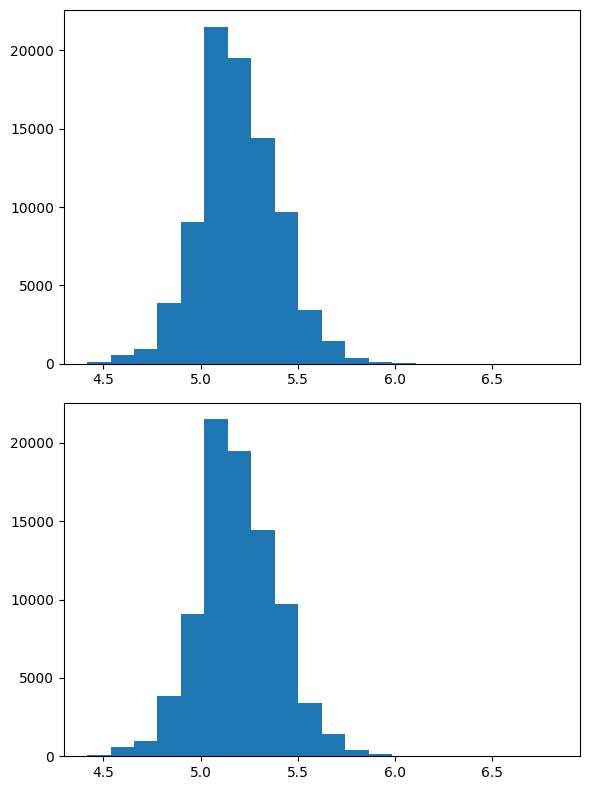

In [ ]:
fig,axs = plt.subplots(2,1,figsize=(6,8))
for ax in axs:
    print(f'kurtosis (non-normalness): {np.log10(applications.amt_income_total).kurtosis()}')
    print(f'skew: {np.log10(applications.amt_income_total).skew()}\n')
    ax.hist(np.log10(applications.amt_income_total),bins=20)
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns

In [ ]:
applications.select_dtypes('float64').columns

Index(['amt_income_total', 'days_birth', 'days_employed', 'flag_mobil',
       'flag_work_phone', 'flag_phone', 'flag_email', 'cnt_fam_members'],
      dtype='object')

In [ ]:
sns.set_context("notebook",font_scale=.7,rc={"grid.linewidth": 0.1,'patch.linewidth': 0.0,
    "axes.grid":True,
    "grid.linestyle": "-",
    "axes.titlesize" : 13,
    "figure.autolayout":True})

palette_1 = ['#FF5E5B','#EC9B9A','#00CECB','#80DE99','#C0E680','#FFED66']

sns.set_palette(sns.color_palette(sns.color_palette(palette_1)))e

<Figure size 1000x1000 with 0 Axes>

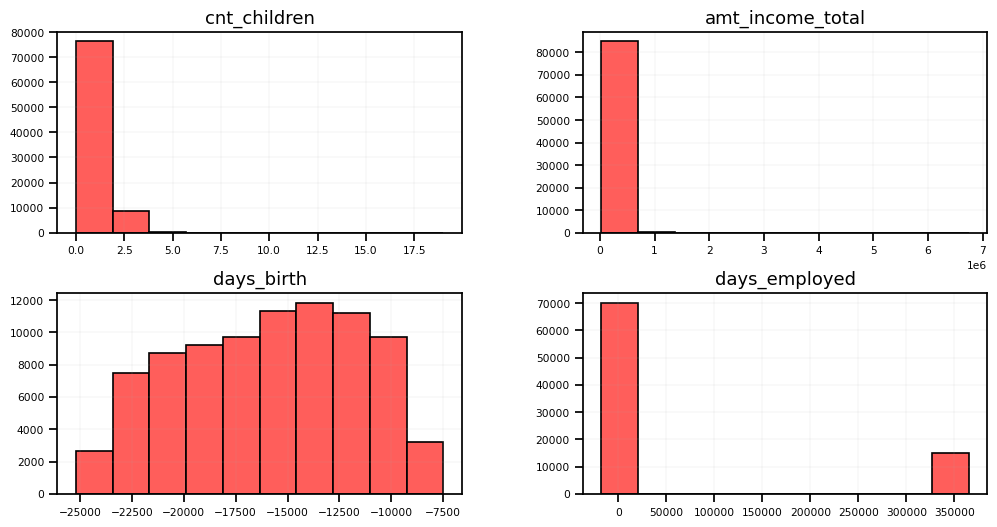

In [ ]:
plt.figure(figsize=(10,10))

cols_to_plot = ["cnt_children","amt_income_total","days_birth","days_employed"]
applications[cols_to_plot].hist(edgecolor='black', linewidth=1.2)
fig=plt.gcf()
fig.set_size_inches(12,6)

<Figure size 1000x1000 with 0 Axes>

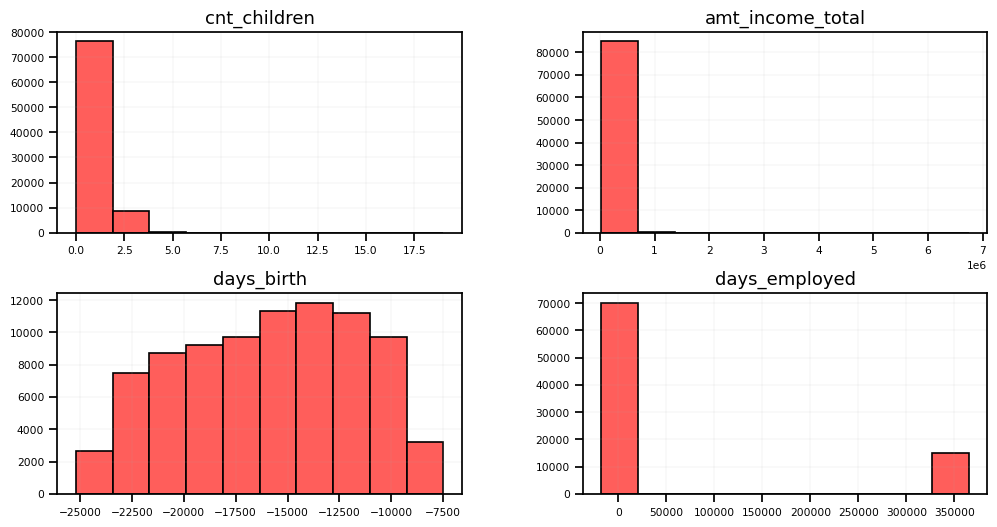

In [ ]:
plt.figure(figsize=(10,10))

cols_to_plot = ["cnt_children","amt_income_total","days_birth","days_employed"]
applications[cols_to_plot].hist(edgecolor='black', linewidth=1.2)
fig=plt.gcf()
fig.set_size_inches(12,6)

There are outliers in 2 columns.

1. cnt_children
2. amt_income_total
3. days_of_employed

### Numeric Features

<Axes: >

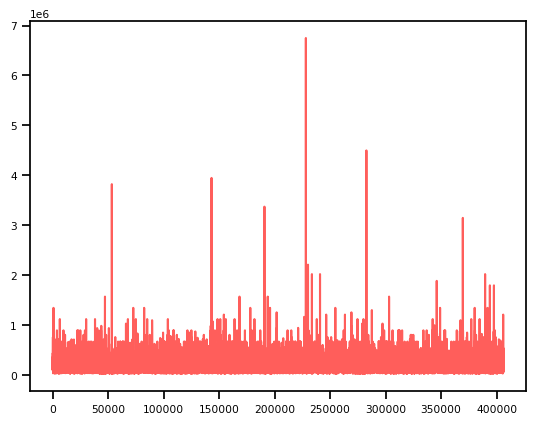

In [ ]:
applications['amt_income_total'].plot()

### Density plot

In [ ]:
applications.describe()

,id,cnt_children,amt_income_total,days_birth,days_employed,flag_mobil,flag_work_phone,flag_phone,flag_email,cnt_fam_members
count,8.509000e+04,85090.000000,8.509000e+04,85089.000000,85089.000000,85089.0,85089.000000,85089.000000,85089.000000,85089.000000
mean,5.868417e+06,0.422318,1.787326e+05,-15906.862591,61785.145283,1.0,0.203951,0.275664,0.100824,2.178307
std,4.926640e+05,0.726652,1.029208e+05,4260.354368,139622.248017,0.0,0.402935,0.446851,0.301097,0.905166
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.439492e+06,0.000000,1.125000e+05,-19444.000000,-2870.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,5.927648e+06,0.000000,1.575000e+05,-15570.000000,-1296.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.233817e+06,1.000000,2.250000e+05,-12340.000000,-322.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,6.839787e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [ ]:
applications.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85090 entries, 0 to 406229
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   85090 non-null  int64  
 1   code_gender          85090 non-null  object 
 2   flag_own_car         85090 non-null  object 
 3   flag_own_realty      85090 non-null  object 
 4   cnt_children         85090 non-null  int64  
 5   amt_income_total     85090 non-null  float64
 6   name_income_type     85090 non-null  object 
 7   name_education_type  85090 non-null  object 
 8   name_family_status   85089 non-null  object 
 9   name_housing_type    85089 non-null  object 
 10  days_birth           85089 non-null  float64
 11  days_employed        85089 non-null  float64
 12  flag_mobil           85089 non-null  float64
 13  flag_work_phone      85089 non-null  float64
 14  flag_phone           85089 non-null  float64
 15  flag_email           85089 non-null  flo

/tmp/ipython-input-3580447255.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(applications['amt_income_total'],shade=True)


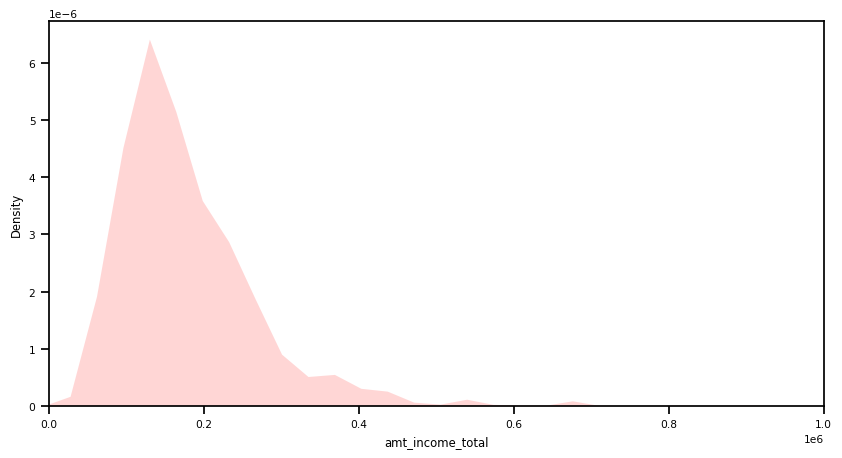

In [ ]:
plt.figure(figsize=(10,5))
plt.xlim(0,1000000)
plt.xlabel('amt_income_total')
plt.ylabel('Density')
sns.kdeplot(applications['amt_income_total'],shade=True)
plt.show()

### most in 10,000 to 400,000

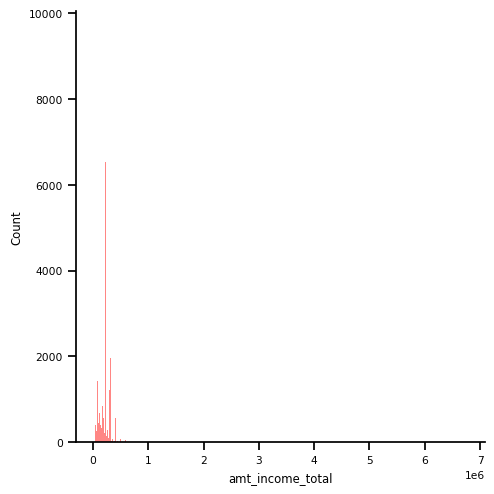

In [ ]:
sns.displot(applications, x="amt_income_total")

### Boxplot

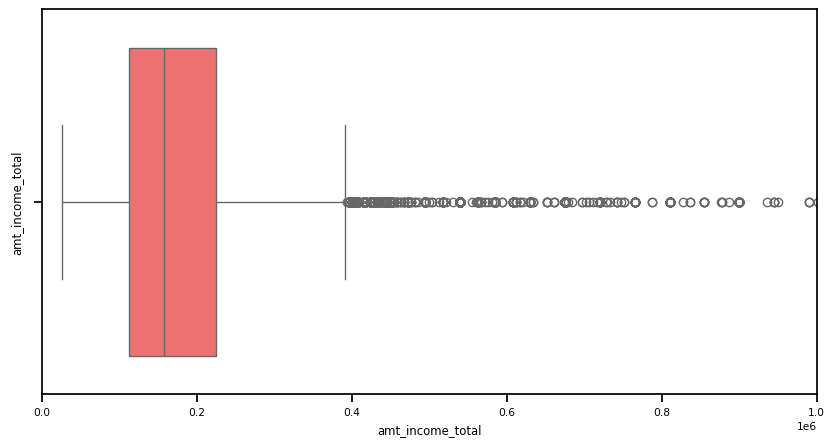

In [ ]:
plt.figure(figsize=(10,5))
plt.xlim(0,1000000)
plt.ylabel('amt_income_total')
sns.boxplot(x=applications['amt_income_total'])
plt.show()

### Categorical Variable

In [ ]:
applications.select_dtypes('object').columns

Index(['code_gender', 'flag_own_car', 'flag_own_realty', 'name_income_type',
       'name_education_type', 'name_family_status', 'name_housing_type',
       'occupation_type'],
      dtype='object')

In [ ]:
categorical_cols = applications.select_dtypes('object').columns

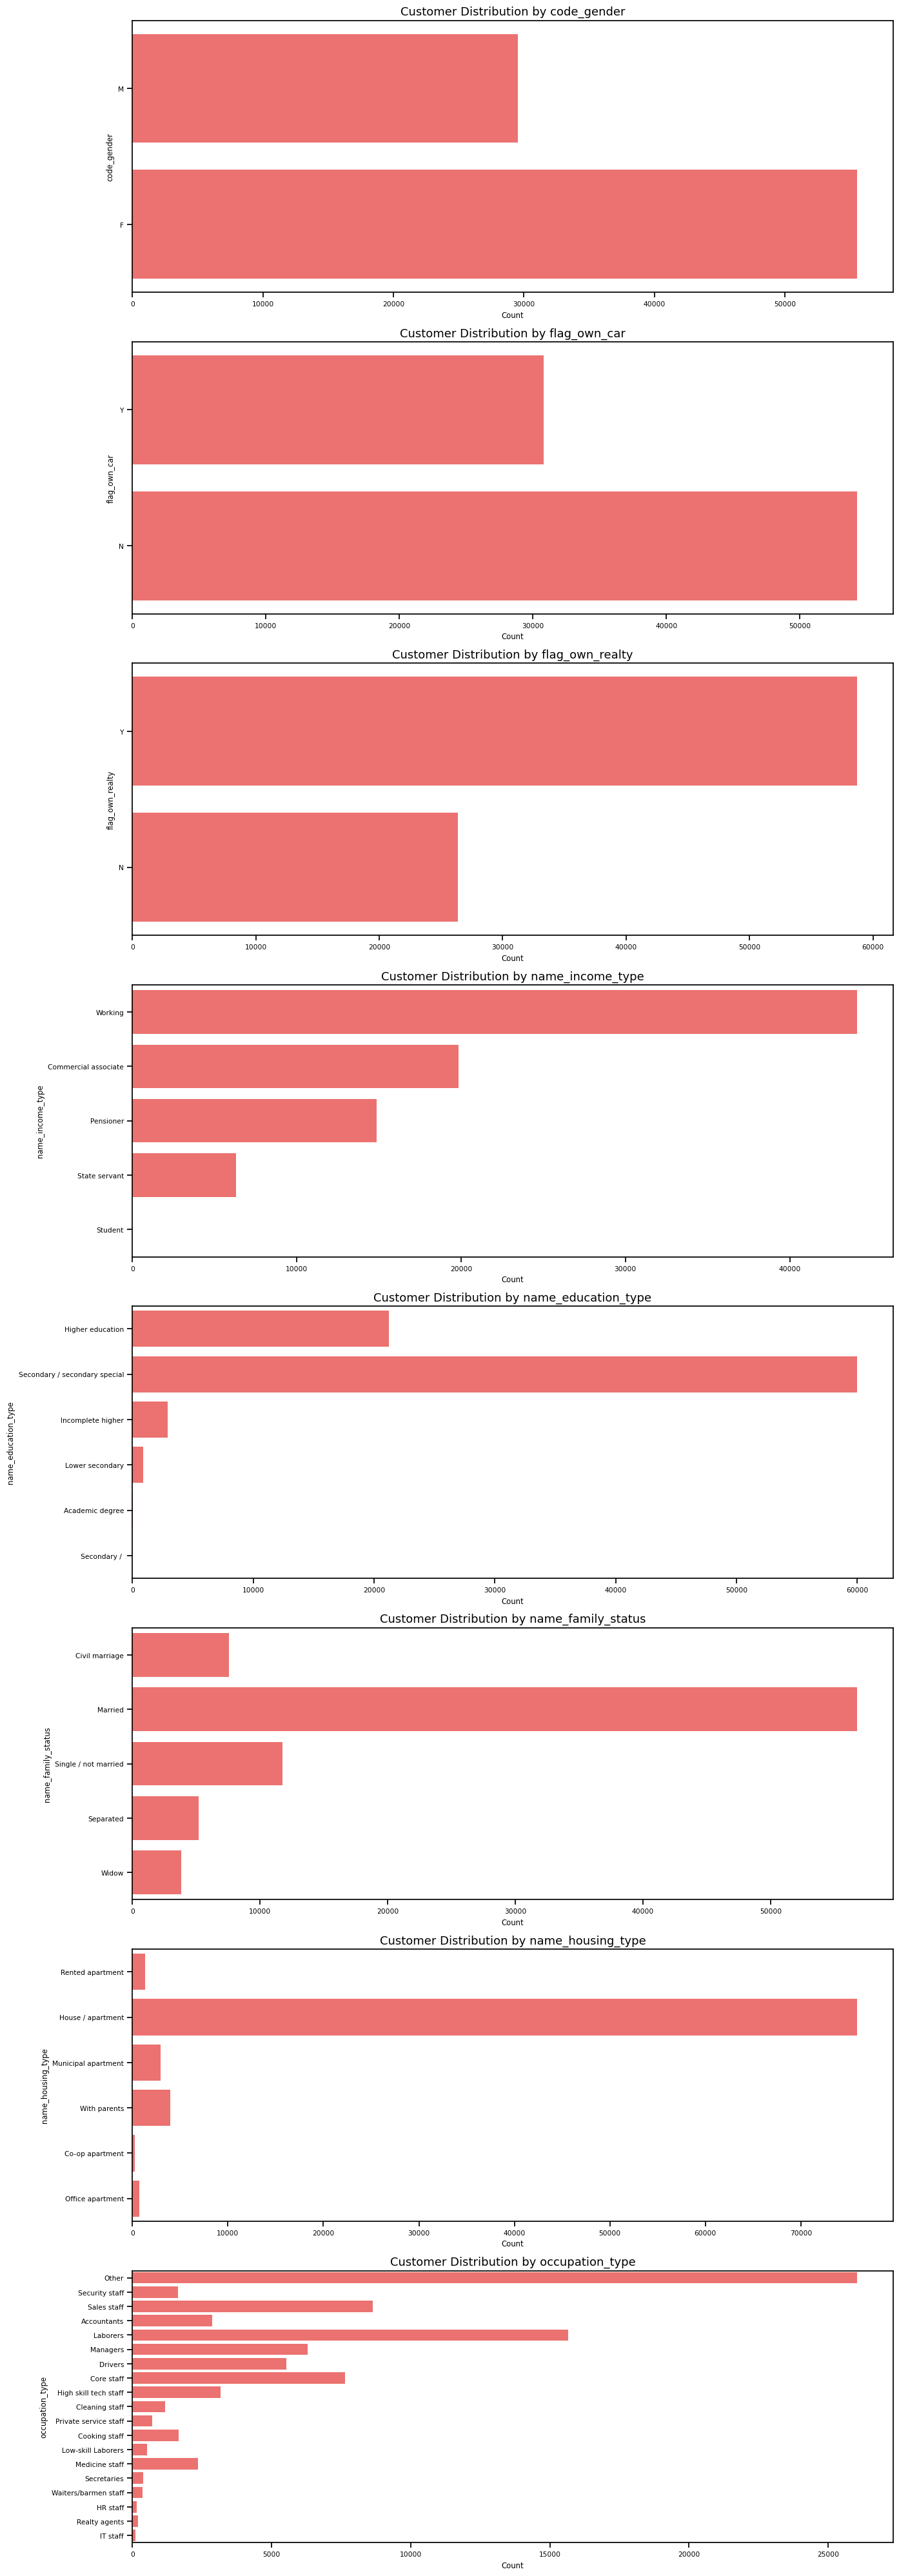

In [ ]:
fig, axes = plt.subplots(8,1)

for ax, (i, col) in zip(axes,enumerate(categorical_cols)):
    g1=sns.countplot(y=applications[col],linewidth=1.2, ax=axes[i])
    g1.set_title("Customer Distribution by {}".format(col))
    g1.set_xlabel("Count")


fig.set_size_inches(14,40)

plt.tight_layout()


plt.show()

In [ ]:
applications.head()

,id,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,name_income_type,name_education_type,name_family_status,name_housing_type,days_birth,days_employed,flag_mobil,flag_work_phone,flag_phone,flag_email,occupation_type,cnt_fam_members
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,Other,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474.0,-1134.0,1.0,0.0,0.0,0.0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464.0,365243.0,1.0,0.0,0.0,0.0,Other,1.0
10,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-16872.0,-769.0,1.0,1.0,1.0,1.0,Accountants,2.0


In [ ]:
applications.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85090 entries, 0 to 406229
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   85090 non-null  int64  
 1   code_gender          85090 non-null  object 
 2   flag_own_car         85090 non-null  object 
 3   flag_own_realty      85090 non-null  object 
 4   cnt_children         85090 non-null  int64  
 5   amt_income_total     85090 non-null  float64
 6   name_income_type     85090 non-null  object 
 7   name_education_type  85090 non-null  object 
 8   name_family_status   85089 non-null  object 
 9   name_housing_type    85089 non-null  object 
 10  days_birth           85089 non-null  float64
 11  days_employed        85089 non-null  float64
 12  flag_mobil           85089 non-null  float64
 13  flag_work_phone      85089 non-null  float64
 14  flag_phone           85089 non-null  float64
 15  flag_email           85089 non-null  flo

## Feature Engineering

### Busines Goal: issue credit card or not?
- decision to make


### Decision Reason
- issue card -> because he's low-risk customer
- not issue card -> because he's high-risk customer



### Bank Process

customer -> with all info/features -> output: low-risk then issue card

## Create target variable

In [ ]:
record.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   id              1048575 non-null  int64 
 1   months_balance  1048575 non-null  int64 
 2   status          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


* Because the credit records are incomplete (the ID ranges in both dfs don't match) we have to create our own target. We do this by identifying 'low risk' and 'high risk' credit users. We say a user is 'high risk' if during any month they are late on payments by 30 days or more, and 'low risk' otherwise. This is the target we will try to predict later.

In [ ]:
# Construct target
record['target']=record['status']
record['target'].replace('X', 0, inplace=True)
record['target'].replace('C', 0, inplace=True)
record['target']=record['target'].astype(int)
record.loc[record['target']>=1,'target']=1

# target=1 (high risk) if there is at least one month where user is late on payments by 30 days or more
target_df=pd.DataFrame(record.groupby(['id'])['target'].agg(max)).reset_index()

# Merge dataframes
new_df=pd.merge(applications, target_df, how='inner', on=['id'])

/tmp/ipython-input-1535763369.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  record['target'].replace('X', 0, inplace=True)
/tmp/ipython-input-1535763369.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [ ]:
record.head()

,id,months_balance,status,target
0,5001711,0,X,0
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,0


### New Feature 1: Account length

* It makes sense that the number of months the account has been open for correlates with the riskiness of the customer (since there are more opportunity to miss payments).

In [ ]:
# Extract how many months account has been open for
start_df=pd.DataFrame(record.groupby(['id'])['months_balance'].agg('min')).reset_index()

# Rename column
start_df.rename(columns={'months_balance':'account_length'}, inplace=True)

# Make entries positive
start_df['account_length']=-start_df['account_length']

# Merge dataframes on ID
new_df=pd.merge(new_df, start_df, how='inner', on=['id'])

### Continuous Features

### New Feature 2: Create age feature

In [ ]:
# Create age feature
new_df['years_employed'] = new_df['days_employed'].replace(365243, np.nan) * -1 / 365.2425

In [ ]:
#How much of their life has been spent working
new_df['age_years'] = -new_df['days_birth'] / 365.2425
new_df['work_age_ratio'] = new_df['years_employed'] / new_df['age_years']
#years_employed in short terms ans long terms
new_df['employment_length_cat'] = pd.cut(
    new_df['years_employed'],
    bins=[-1, 1, 5, 10, 20, 50, 100],
    labels=['<1yr', '1-5yrs', '5-10yrs', '10-20yrs', '20-50yrs', '50+yrs']
)
#retirement
new_df['is_retirement_age'] = (new_df['age_years'] >= 60).astype(int)

In [ ]:
new_df['work_age_ratio_cat'] = pd.cut(
    new_df['work_age_ratio'],
    bins=[-0.01, 0.2, 0.5, 0.8, 1.0, 2.0],
    labels=['<0.2', '0.2–0.5', '0.5–0.8', '0.8–1.0', '>1.0']
)
print("\n=== work_age_ratio_cat 分类频率 ===")
print(new_df['work_age_ratio_cat'].value_counts(dropna=False))

print("\n=== employment_length_cat 分布 ===")
print(new_df['employment_length_cat'].value_counts(dropna=False))
new_df['has_employment_record'] = new_df['years_employed'].notna().astype(int)

new_df['employment_length_cat'] = (
    new_df['employment_length_cat']
      .astype('category')
      .cat.add_categories('Unemployed/Unknown')
      .fillna('Unemployed/Unknown')
)
new_df['years_employed_filled'] = new_df['years_employed'].fillna(0)
new_df['work_age_ratio_filled'] = (
    new_df['years_employed_filled'] / new_df['age_years']
).replace([np.inf, -np.inf], np.nan)

ratio_bins  = [0, 0.1, 0.3, 0.5, 0.8, 1.2]
ratio_lbls  = ['<0.1','0.1–0.3','0.3–0.5','0.5–0.8','0.8–1.0+']
new_df['work_age_ratio_cat2'] = pd.cut(new_df['work_age_ratio_filled'],
                                       bins=ratio_bins, labels=ratio_lbls)

new_df['work_age_ratio_cat2'] = new_df['work_age_ratio_cat2'].astype('category') \
    .cat.add_categories('Unemployed/Unknown') \
    .fillna('Unemployed/Unknown')
print("\n=== work_age_ratio_cat2 分类频率 ===")
print(new_df['work_age_ratio_cat2'].value_counts())

print("\n=== employment_length_cat（含Unemployed/Unknown）分布 ===")
print(new_df['employment_length_cat'].value_counts())

# work_age_ratio_cat2 — categorized ratio of employment years to age.
# employment_length_cat — categorized total years employed.
# is_retirement_age — indicator of whether age is above 60.


=== work_age_ratio_cat 分类频率 ===
work_age_ratio_cat
<0.2       5426
0.2–0.5    2239
NaN        1669
0.5–0.8     258
0.8–1.0       0
>1.0          0
Name: count, dtype: int64

=== employment_length_cat 分布 ===
employment_length_cat
1-5yrs      3221
5-10yrs     2176
NaN         1669
10-20yrs    1339
<1yr         780
20-50yrs     407
50+yrs         0
Name: count, dtype: int64

=== work_age_ratio_cat2 分类频率 ===
work_age_ratio_cat2
0.1–0.3               3520
<0.1                  3169
Unemployed/Unknown    1669
0.3–0.5                976
0.5–0.8                258
0.8–1.0+                 0
Name: count, dtype: int64

=== employment_length_cat（含Unemployed/Unknown）分布 ===
employment_length_cat
1-5yrs                3221
5-10yrs               2176
Unemployed/Unknown    1669
10-20yrs              1339
<1yr                   780
20-50yrs               407
50+yrs                   0
Name: count, dtype: int64


### New Feature 3:  Create unemployed indicator

In [ ]:
# Create unemployed indicator
new_df['unemployed']=0
new_df.loc[-new_df['days_employed']<0,'unemployed']=1

### New Feature 4:  Encoding categorical features

In [ ]:
# Encode binary features
new_df["code_gender"]     = new_df["code_gender"].replace({"F":0, "M":1, "XNA":np.nan})
new_df["flag_own_car"]    = new_df["flag_own_car"].map({"Y":1, "N":0})
new_df["flag_own_realty"] = new_df["flag_own_realty"].map({"Y":1, "N":0})

/tmp/ipython-input-3979150680.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_df["code_gender"]     = new_df["code_gender"].replace({"F":0, "M":1, "XNA":np.nan})


In [ ]:
std = lambda s: s.astype(str).str.strip().str.lower()

inc  = std(new_df["name_income_type"])
edu  = std(new_df["name_education_type"])
house= std(new_df["name_housing_type"])

print("=== name_income_type (top 20) ===")
display(inc.value_counts(dropna=False).head(20))

print("=== name_education_type (top 20) ===")
display(edu.value_counts(dropna=False).head(20))

print("=== name_housing_type (top 20) ===")
display(house.value_counts(dropna=False).head(20))


=== name_income_type (top 20) ===


,count
name_income_type,
working,4915
commercial associate,2289
pensioner,1669
state servant,716
student,3


=== name_education_type (top 20) ===


,count
name_education_type,
secondary / secondary special,6678
higher education,2425
incomplete higher,370
lower secondary,113
academic degree,6


=== name_housing_type (top 20) ===


,count
name_housing_type,
house / apartment,8587
with parents,442
municipal apartment,312
rented apartment,141
office apartment,76
co-op apartment,34


In [ ]:
import numpy as np
import pandas as pd

def _norm(s: pd.Series):
    return (s.astype("string")
              .str.strip()
              .str.lower()
              .str.replace(r"\s+", " ", regex=True))

new_df["name_income_type_"]    = _norm(new_df["name_income_type"])
new_df["name_education_type_"] = _norm(new_df["name_education_type"])
new_df["name_housing_type_"]   = _norm(new_df["name_housing_type"])

#1) IncomeEmployed
employed_set   = {"working", "commercial associate", "state servant"}
unemployed_set = {"pensioner", "student"}

new_df["IncomeEmployed"] = np.where(new_df["name_income_type_"].isin(employed_set), 1, 0)

# 2) EduHigherPlus
higher_plus = {"higher education", "academic degree"}
new_df["EduHigherPlus"] = np.where(new_df["name_education_type_"].isin(higher_plus), 1, 0)


# 3) HousingOwned
owned_set   = {"house / apartment", "co-op apartment"}
not_owned   = {"with parents", "municipal apartment", "rented apartment", "office apartment"}

new_df["HousingOwned"] = np.where(new_df["name_housing_type_"].isin(owned_set), 1, 0)

new_df[["IncomeEmployed","EduHigherPlus","HousingOwned"]] = \
    new_df[["IncomeEmployed","EduHigherPlus","HousingOwned"]].fillna(0).astype("int8")


display(new_df[["name_income_type","IncomeEmployed",
                "name_education_type","EduHigherPlus",
                "name_housing_type","HousingOwned"]].head())


print(new_df["IncomeEmployed"].value_counts(dropna=False))
print(new_df["EduHigherPlus"].value_counts(dropna=False))
print(new_df["HousingOwned"].value_counts(dropna=False))


,name_income_type,IncomeEmployed,name_education_type,EduHigherPlus,name_housing_type,HousingOwned
0,Working,1,Higher education,1,Rented apartment,0
1,Working,1,Secondary / secondary special,0,House / apartment,1
2,Commercial associate,1,Secondary / secondary special,0,House / apartment,1
3,Pensioner,0,Higher education,1,House / apartment,1
4,Working,1,Higher education,1,House / apartment,1


IncomeEmployed
1    7920
0    1672
Name: count, dtype: int64
EduHigherPlus
0    7161
1    2431
Name: count, dtype: int64
HousingOwned
1    8621
0     971
Name: count, dtype: int64


## Data Validation & Summarize

In [ ]:

New_Features = {
    'age_years':'B|Demo&Emp',
    'years_employed':'B|Demo&Emp',
    'work_age_ratio':'B|Demo&Emp',
    'employment_length_cat':'B|Demo&Emp',
    'is_retirement_age':'B|Demo&Emp',
    'work_age_ratio_cat':'B|Demo&Emp',
    'work_age_ratio_cat2':'B|Demo&Emp',
    'has_employment_record':'B|Demo&Emp',
    'unemployed':'B|Demo&Emp',

    'years_employed_filled':'B|Demo&Emp',
    'work_age_ratio_filled':'B|Demo&Emp',
    'IncomeEmployed':'C|categorical',
    'EduHigherPlus':'C|categorical',
    'HousingOwned':'C|categorical',
    'name_income_type_':'C|categorical',
    'name_education_type_':'C|categorical',
    'name_housing_type_':'C|categorical'
}

all_features = list(New_Features.keys())
exist_cols   = [c for c in all_features if c in new_df.columns]
missing_cols = [c for c in all_features if c not in new_df.columns]

print("已找到的特征数量/应有数量:", len(exist_cols), "/", len(all_features))
if missing_cols:
    print("⚠️ 以下分组映射中的列目前在 new_df 不存在：", missing_cols)


feat_groups = (pd.DataFrame({'feature': exist_cols})
                 .assign(group=lambda d: d['feature'].map(New_Features)))


print("\n=== 分组计数 ===")
print(feat_groups.groupby('group')['feature'].count().sort_index())

已找到的特征数量/应有数量: 17 / 17

=== 分组计数 ===
group
B|Demo&Emp       11
C|categorical     6
Name: feature, dtype: int64


In [ ]:
df = new_df.copy()

n = len(df)
m = (df.isna().sum()
       .to_frame("n_missing")
       .assign(missing_rate=lambda x: (x["n_missing"]/n).round(4))
       .rename_axis("feature").reset_index())
m = m[m.n_missing > 0].sort_values("n_missing", ascending=False)
print("\n=== 缺失值（仅有缺失）===")
display(m if not m.empty else "无缺失列")

# 2) IQR Clipping
num_all = df.select_dtypes(include=[np.number]).columns.tolist()
cont = [c for c in num_all if c != "target" and df[c].nunique(dropna=True) > 5]

clipped, before = [], []
for c in cont:
    x = df[c].dropna()
    if x.empty: continue
    q1, q3 = x.quantile([0.25, 0.75]); iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0: continue
    lo, up = q1 - 1.5*iqr, q3 + 1.5*iqr
    r = ((x < lo) | (x > up)).mean()
    if r > 0:
        before.append({"feature": c, "outlier_rate_before": float(r)})
        df[c] = df[c].clip(lo, up)
        clipped.append(c)

print("\n=== 裁剪列数：", len(clipped), "===")
if clipped: print("列：", clipped)


if clipped:
    rows = []
    for c in clipped:
        x = df[c].dropna()
        if x.empty:
            rate = 0.0
        else:
            q1, q3 = x.quantile([0.25, 0.75]); iqr = q3 - q1
            if pd.isna(iqr) or iqr == 0: rate = 0.0
            else:
                lo, up = q1 - 1.5*iqr, q3 + 1.5*iqr
                rate = ((x < lo) | (x > up)).mean()
        rows.append({"feature": c, "outlier_rate_after": float(rate)})
    cmp_df = pd.DataFrame(before).merge(pd.DataFrame(rows), on="feature").sort_values("outlier_rate_before", ascending=False)
    print("\n=== 裁剪前 vs 裁剪后（仅裁剪过的列）===")
    display(cmp_df)
    if (cmp_df["outlier_rate_after"] <= 1e-12).all(): print("✅ 裁剪后占比均为 0（或数值误差）")

clean_df = df.copy()


=== 缺失值（仅有缺失）===


,feature,n_missing,missing_rate
20,years_employed,1669,0.174
22,work_age_ratio,1669,0.174
25,work_age_ratio_cat,1669,0.174



=== 裁剪列数： 8 ===
列： ['cnt_children', 'amt_income_total', 'days_employed', 'cnt_fam_members', 'years_employed', 'work_age_ratio', 'years_employed_filled', 'work_age_ratio_filled']

=== 裁剪前 vs 裁剪后（仅裁剪过的列）===


,feature,outlier_rate_before,outlier_rate_after
2,days_employed,0.222164,0.0
4,years_employed,0.053768,0.0
6,years_employed_filled,0.048165,0.0
5,work_age_ratio,0.033826,0.0
1,amt_income_total,0.032631,0.0
7,work_age_ratio_filled,0.031276,0.0
0,cnt_children,0.015325,0.0
3,cnt_fam_members,0.014283,0.0


✅ 裁剪后占比均为 0（或数值误差）


In [ ]:
pd.DataFrame({"dtype":df.dtypes.astype(str),
        "n_unique":df.nunique(dropna=True),
        "n_missing":df.isna().sum(),
        "missing_rate":df.isna().mean()}).rename_axis("feature").reset_index()

,feature,dtype,n_unique,n_missing,missing_rate
0,id,int64,9592,0,0.000000
1,code_gender,int64,2,0,0.000000
2,flag_own_car,int64,2,0,0.000000
3,flag_own_realty,int64,2,0,0.000000
4,cnt_children,float64,4,0,0.000000
5,amt_income_total,float64,220,0,0.000000
6,name_income_type,object,5,0,0.000000
7,name_education_type,object,5,0,0.000000
8,name_family_status,object,5,0,0.000000
9,name_housing_type,object,6,0,0.000000


## Model Building & Comparison

### Before modeling, advanced data preprocessing for categorical variable

In [ ]:
import pandas as pd, numpy as np


base_df = globals().get('clean_df', globals().get('new_df', None))
if base_df is None:
    raise RuntimeError
base_df = base_df.copy()


if 'age_years' not in base_df and 'days_birth' in base_df:
    base_df['age_years'] = -base_df['days_birth'] / 365.2425

if 'years_employed' not in base_df and 'days_employed' in base_df:
    tmp = base_df['days_employed'].replace(365243, np.nan) * -1 / 365.2425
    base_df['years_employed'] = tmp.where(tmp >= 0)

if 'years_employed_filled' not in base_df and 'years_employed' in base_df:
    base_df['years_employed_filled'] = base_df['years_employed'].fillna(0)

if 'work_age_ratio' not in base_df and {'years_employed','age_years'}.issubset(base_df.columns):
    with np.errstate(divide='ignore', invalid='ignore'):
        base_df['work_age_ratio'] = (base_df['years_employed'] / base_df['age_years']).replace([np.inf,-np.inf], np.nan)

if 'work_age_ratio_filled' not in base_df and {'years_employed_filled','age_years'}.issubset(base_df.columns):
    with np.errstate(divide='ignore', invalid='ignore'):
        base_df['work_age_ratio_filled'] = (base_df['years_employed_filled'] / base_df['age_years']).replace([np.inf,-np.inf], np.nan)


if 'flag_mobil' in base_df and base_df['flag_mobil'].nunique(dropna=False) <= 1:
    base_df.drop(columns=['flag_mobil'], inplace=True)


if 'years_employed_num' not in base_df:
    src = 'years_employed_filled' if 'years_employed_filled' in base_df else 'years_employed'
    if src in base_df: base_df['years_employed_num'] = base_df[src]
if 'work_age_ratio_num' not in base_df:
    src = 'work_age_ratio_filled' if 'work_age_ratio_filled' in base_df else 'work_age_ratio'
    if src in base_df: base_df['work_age_ratio_num'] = base_df[src]


cat_candidates = [
    'employment_length_cat','work_age_ratio_cat','work_age_ratio_cat2',
    'name_income_type','name_education_type','name_family_status',
    'name_housing_type','occupation_type'
]
cat_cols = [c for c in cat_candidates if c in base_df.columns]
for c in cat_cols:
    base_df[c] = base_df[c].astype('category')
    if base_df[c].isna().any():
        base_df[c] = base_df[c].cat.add_categories(['Unknown']).fillna('Unknown')

if cat_cols:
    base_df = pd.get_dummies(base_df, columns=cat_cols, drop_first=True, dummy_na=False)


if 'target' not in base_df.columns:
    raise RuntimeError("未找到 target 列，确认标签已合并。")

id_col = 'id' if 'id' in base_df.columns else None
num_cols = [c for c in base_df.columns
            if c not in ['target', id_col] and pd.api.types.is_numeric_dtype(base_df[c])]

model_df = base_df[num_cols + ['target']].copy().fillna(0)
y_ready = model_df['target'].astype(int)
X_ready = model_df.drop(columns=['target'])
X, y = X_ready, y_ready

print("=== 建模数据就绪 ===")
print(f"样本量: {len(model_df):,} | 特征数: {X_ready.shape[1]:,}")
print(y_ready.value_counts().rename('count'))
print("数值副本：", [c for c in X_ready.columns if c.endswith('_num')])



=== 建模数据就绪 ===
样本量: 9,592 | 特征数: 76
target
0    8426
1    1166
Name: count, dtype: int64
数值副本： ['years_employed_num', 'work_age_ratio_num']


### Modelling

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


In [ ]:
#SMOTE oversampling
sm = SMOTE(random_state=42)
y_ready = y.astype('int')
X_balance, y_balance = sm.fit_resample(X_ready, y_ready)
X_balance = pd.DataFrame(X_balance, columns=X_ready.columns)

print("After SMOTE oversampling:")
print(y_balance.value_counts())
#After over sampling, the number between 1 and 0 is balanced.
#test train split
X_train, X_test, y_train, y_test = train_test_split(X_balance,y_balance,
                                                    stratify=y_balance, test_size=0.3,
                                                    random_state = 10086)
print("Train size:", len(X_train))
print("Test size:", len(X_test))

After SMOTE oversampling:
target
1    8426
0    8426
Name: count, dtype: int64
Train size: 11796
Test size: 5056


### Baseline: Random Forest

In [ ]:
# Random Forest Baseline

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score
)
import pandas as pd

# prevent overfitting
rf = RandomForestClassifier(
    random_state=42,
    min_samples_leaf=16
)

# hyperparameter tuning
param_grid = {
    'max_depth': [3, 5, 8, 10],
    'n_estimators': [200, 400, 600]
}

# 5-fold GridSearchCV
grid = GridSearchCV(
    rf,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=2
)


grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("\n=== 最佳參數組合 ===")
print(grid.best_params_)

y_predict = best_rf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_predict)
print("\nConfusion Matrix:")
print(pd.DataFrame(cm, index=['Actual 0','Actual 1'], columns=['Pred 0','Pred 1']))

acc = accuracy_score(y_test, y_predict)
prec = precision_score(y_test, y_predict)
rec = recall_score(y_test, y_predict)
f1 = f1_score(y_test, y_predict)

print("\n=== Classification Metrics ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== 最佳參數組合 ===
{'max_depth': 10, 'n_estimators': 200}

Confusion Matrix:
          Pred 0  Pred 1
Actual 0    2442      86
Actual 1     473    2055

=== Classification Metrics ===
Accuracy : 0.8894
Precision: 0.9598
Recall   : 0.8129
F1-score : 0.8803


The baseline model performs consistently, achieving an overall accuracy of **88.9%**.

A high precision (**95%**) means the model is very accurate when predicting **"bad" customers**, so the bank is unlikely to mistakenly reject good customers.

Recall is slightly lower (**81.3%**), indicating that some high-risk customers are still not detected.

Overall, the F1 score is **0.88**, showing a good balance between precision and recall.

### XGBoost Classifier

Fitting 5 folds for each of 10 candidates, totalling 50 fits

=== 最佳參數組合 ===
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Confusion Matrix:
          Pred 0  Pred 1
Actual 0    2504      24
Actual 1     377    2151

=== XGBoost (Random CV) Performance ===
Accuracy : 0.9207
Precision: 0.9890
Recall   : 0.8509
F1-score : 0.9147
AUC      : 0.9427


<Figure size 1000x600 with 0 Axes>

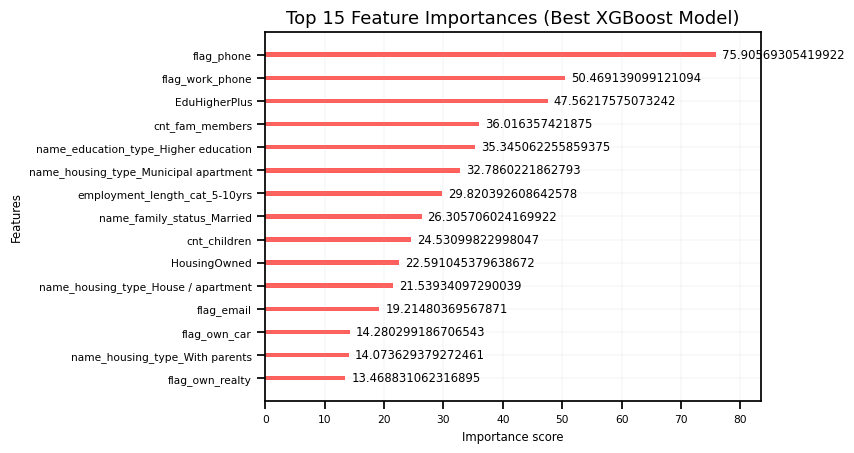

In [ ]:
# XGBoost with RandomizedSearchCV


import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
import pandas as pd
import matplotlib.pyplot as plt

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

xgb_params = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# RandomizedSearchCV
xgb_random = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_params,
    n_iter=10,
    scoring='recall',
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

xgb_random.fit(X_train, y_train)

print("\n=== 最佳參數組合 ===")
print(xgb_random.best_params_)

best_xgb = xgb_random.best_estimator_
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

# Eval Metrics
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\nConfusion Matrix:")
print(pd.DataFrame(cm, index=['Actual 0','Actual 1'], columns=['Pred 0','Pred 1']))

print("\n=== XGBoost (Random CV) Performance ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

plt.figure(figsize=(10,6))
xgb.plot_importance(best_xgb, max_num_features=15, importance_type='gain')
plt.title("Top 15 Feature Importances (Best XGBoost Model)")
plt.show()



After hyperparameter tuning with randomized search, the XGBoost model reaches a strong balance: **Accuracy 0.92**, **Precision 0.98**, **Recall 0.85**, **AUC 0.94**.
Compared with the baseline, it captures more high-risk customers while keeping the false-rejection rate extremely low.

The model only misclassified **24** "good" customers as "bad" (very few false positives).

It correctly identified **2,151** high-risk customers, which is **85.1%** of all high-risk samples.
...
**377** high-risk customers were still predicted as safe, which is lower than the baseline.

### LightGBM

In [ ]:
# LightGBM + RandomizedSearchCV
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)
import pandas as pd
import numpy as np

lgb_model = lgb.LGBMClassifier(
    objective='binary',
    random_state=42,
    n_jobs=-1
)

lgb_params = {
    'learning_rate':   [0.01, 0.05, 0.1],
    'n_estimators':    [100, 300, 500],
    'max_depth':       [-1, 5, 7],
    'num_leaves':      [31, 63, 127],
    'subsample':       [0.8, 1.0],
    'colsample_bytree':[0.8, 1.0],
}

# RandomizedSearchCV
lgb_random = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=lgb_params,
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)


lgb_random.fit(X_train, y_train)


best_lgb = lgb_random.best_estimator_
y_pred = best_lgb.predict(X_test)
y_prob = best_lgb.predict_proba(X_test)[:, 1]

print("\n=== 最佳參數組合 ===")
print(lgb_random.best_params_)


cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(pd.DataFrame(cm, index=['Actual 0','Actual 1'], columns=['Pred 0','Pred 1']))


acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n=== LightGBM (Random CV) Performance ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")


imp = pd.Series(best_lgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 15 Feature Importances:")
print(imp.head(15))




Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 5898, number of negative: 5898
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005930 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3961
[LightGBM] [Info] Number of data points in the train set: 11796, number of used features: 71
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

=== 最佳參數組合 ===
{'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 100, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Confusion Matrix:
          Pred 0  Pred 1
Actual 0    2511      17
Actual 1     395    2133

=== LightGBM (Random CV) Performance ===
Accuracy : 0.9185
Precision: 0.9921
Recall   : 0.8438
F1-score : 0.9119
AUC      : 

This LightGBM model is very stable and well-balanced. On the test set, it achieves **Accuracy 0.9185**, **Precision 0.992...**. The tuned hyperparameters (e.g., **subsample=1.0**, **colsample_bytree=1.0**) suggest the model learns feature relationships well without clear signs of overfitting.

Across the three models:

- **Baseline (Random Forest)** provides an initial reference. It achieves **Accuracy 0.889** and **Recall 0.813**, but is relatively conservative.
- **XGBoost** improves to **Accuracy 0.921**, **Recall 0.851**, **AUC 0.943**, indicating better stability and generalization.
- **LightGBM** outperforms XGBoost on **Precision (0.992)** and **AUC (0.948)**. Accuracy and recall are very close, delivering the strongest overall discrimination performance.

<Figure size 1000x600 with 0 Axes>

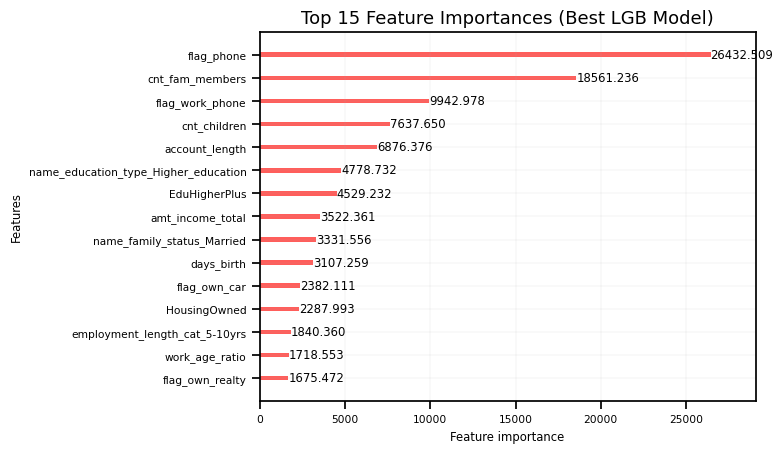

In [ ]:
import matplotlib.pyplot as plt
import lightgbm as lgb


plt.figure(figsize=(10,6))
lgb.plot_importance(best_lgb, max_num_features=15, importance_type='gain')
plt.title("Top 15 Feature Importances (Best LGB Model)")
plt.show()



### Model Optimization & Evaluation

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

# Five CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def report_metrics(y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    return {
        "PR-AUC":  average_precision_score(y_true, proba),
        "ROC-AUC": roc_auc_score(y_true, proba),
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "CM": confusion_matrix(y_true, pred).tolist()}

In [ ]:
# Use XGB to tune hyperparameters
xgb_params = {
    'learning_rate':     [0.08, 0.1, 0.13],
    'n_estimators':      [300, 500, 800, 1100, 1500],
    'max_depth':         [5, 6, 7],
    'subsample':         [0.8, 1.0],
    'colsample_bytree':  [0.8, 1.0]
}

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

xgb_random = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_params,
    n_iter=10,
    scoring='recall',
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

xgb_random.fit(X_train, y_train)
best_xgb = xgb_random.best_estimator_
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("\n=== 最佳參數組合（XGB）===")
print(xgb_random.best_params_)
print("\nConfusion Matrix:")
print(pd.DataFrame(cm, index=['Actual 0','Actual 1'], columns=['Pred 0','Pred 1']))
print(f"\nAccuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")



Fitting 5 folds for each of 10 candidates, totalling 50 fits

=== 最佳參數組合（XGB）===
{'subsample': 0.8, 'n_estimators': 1500, 'max_depth': 6, 'learning_rate': 0.13, 'colsample_bytree': 0.8}

Confusion Matrix:
          Pred 0  Pred 1
Actual 0    2421     107
Actual 1     334    2194

Accuracy : 0.9128
Precision: 0.9535
Recall   : 0.8679
F1-score : 0.9087
ROC-AUC  : 0.9435


In [ ]:
# Maximize recall, and keep precision >= 0.10
p, r, thr = precision_recall_curve(y_train, oof_xgb)

valid_idx = np.where(p >= 0.10)[0]

if len(valid_idx) == 0:
    print("No threshold satisfies precision >= 0.10")
else:
    best_idx = valid_idx[np.argmax(r[valid_idx])]
    thr_best = thr[best_idx-1] if best_idx > 0 else 0.5
    print(f"Best threshold (max recall with precision>=0.10): {thr_best:.4f}")


 # the best on the testing set
    y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]
    y_pred_best_xgb = (y_prob_xgb >= thr_best_xgb).astype(int)
    cm_best = confusion_matrix(y_test, y_pred_best_xgb)

  # Apply to test
    y_pred_custom = (y_prob_xgb >= thr_best).astype(int)

    print("\nConfusion Matrix:")
    print(pd.DataFrame(confusion_matrix(y_test, y_pred_custom),
                       index=['Actual 0','Actual 1'],
                       columns=['Pred 0','Pred 1']))

    print("\nRecall  :", recall_score(y_test, y_pred_custom))
    print("Precision:", precision_score(y_test, y_pred_custom))
    print("F1-score :", f1_score(y_test, y_pred_custom))


Best threshold (max recall with precision>=0.10): 0.5000

Confusion Matrix:
          Pred 0  Pred 1
Actual 0    2421     107
Actual 1     334    2194

Recall  : 0.867879746835443
Precision: 0.9534984789222077
F1-score : 0.908676744667633


In [ ]:
from sklearn.base import clone
from sklearn.metrics import precision_recall_curve, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
import numpy as np
import pandas as pd

# OOF
oof_xgb = np.zeros(len(y_train))
for tr, va in cv.split(X_train, y_train):
    m = clone(best_xgb)
    m.fit(X_train.iloc[tr], y_train.iloc[tr])
    oof_xgb[va] = m.predict_proba(X_train.iloc[va])[:, 1]

# best F1
p, r, thr = precision_recall_curve(y_train, oof_xgb)
f1_curve = 2*p*r/(p+r+1e-12)
idx = int(np.nanargmax(f1_curve))
thr_best_xgb = (thr[idx-1] if idx>0 else 0.5)
print(f"Best threshold (OOF F1-max, XGB): {thr_best_xgb:.3f}")

# the best on the testing
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_best_xgb = (y_prob_xgb >= thr_best_xgb).astype(int)
cm_best = confusion_matrix(y_test, y_pred_best_xgb)

print("\n=== XGBoost Performance @best ===")
print(pd.DataFrame(cm_best, index=['Actual 0','Actual 1'], columns=['Pred 0','Pred 1']))
print(f"\nAccuracy : {accuracy_score(y_test, y_pred_best_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best_xgb, zero_division=0):{'.4f'}}")
print(f"Recall   : {recall_score(y_test, y_pred_best_xgb, zero_division=0):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_best_xgb, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_prob_xgb):.4f}")

Best threshold (OOF F1-max, XGB): 0.446

=== XGBoost Performance @best ===
          Pred 0  Pred 1
Actual 0    2493      35
Actual 1     379    2149

Accuracy : 0.9181
Precision: 0.9840
Recall   : 0.8501
F1-score : 0.9121
ROC-AUC  : 0.9466
PR-AUC   : 0.9635


In [ ]:
# LightGBM hyperparameter tuning
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, average_precision_score)
import pandas as pd
import numpy as np


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


lgb_model = lgb.LGBMClassifier(
    objective='binary',
    random_state=42,
    n_jobs=-1
)


lgb_params = {
    'learning_rate':     [0.03, 0.05, 0.1],
    'n_estimators':      [300, 600, 900, 1200],
    'max_depth':         [-1, 5, 7],
    'num_leaves':        [31, 63, 127],
    'subsample':         [0.8, 1.0],
    'colsample_bytree':  [0.8, 1.0],
}


lgb_random = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=lgb_params,
    n_iter=10,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42,
    refit=True
)

lgb_random.fit(X_train, y_train)
best_lgb = lgb_random.best_estimator_

print("\n=== 最佳參數組合（LGB, C 段）===")
print(lgb_random.best_params_)


y_prob = best_lgb.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1  = f1_score(y_test, y_pred, zero_division=0)
roc = roc_auc_score(y_test, y_prob)
pra = average_precision_score(y_test, y_prob)

print("\n=== LightGBM (Random CV) Performance @0.5 ===")
print(pd.DataFrame(cm, index=['Actual 0','Actual 1'], columns=['Pred 0','Pred 1']))
print(f"\nAccuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")
print(f"PR-AUC   : {pra:.4f}")
# Top 15 Feature Importances
imp = pd.Series(best_lgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 15 Feature Importances:")
print(imp.head(15))


Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 5898, number of negative: 5898
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005994 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3961
[LightGBM] [Info] Number of data points in the train set: 11796, number of used features: 71
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

=== 最佳參數組合（LGB, C 段）===
{'subsample': 0.8, 'num_leaves': 127, 'n_estimators': 600, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

=== LightGBM (Random CV) Performance @0.5 ===
          Pred 0  Pred 1
Actual 0    2471      57
Actual 1     350    2178

Accuracy : 0.9195
Precision: 0.9745
Recall   : 0.8616
F1-score : 0.9145
ROC-AUC  : 0.95

<Figure size 1000x600 with 0 Axes>

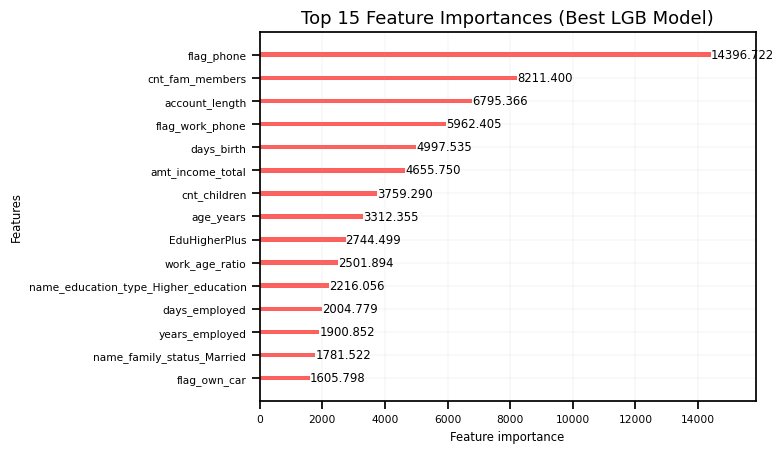

In [ ]:
import matplotlib.pyplot as plt
import lightgbm as lgb


plt.figure(figsize=(10,6))
lgb.plot_importance(best_lgb, max_num_features=15, importance_type='gain')
plt.title("Top 15 Feature Importances (Best LGB Model)")
plt.show()



In [ ]:
from sklearn.base import clone
from sklearn.metrics import precision_recall_curve

# OOF
oof = np.zeros(len(y_train))
for tr, va in cv.split(X_train, y_train):
    m = clone(best_lgb).fit(X_train.iloc[tr], y_train.iloc[tr])
    oof[va] = m.predict_proba(X_train.iloc[va])[:, 1]

# best F1
p, r, thr = precision_recall_curve(y_train, oof)
f1_curve = 2*p*r/(p+r+1e-12)
idx = int(np.nanargmax(f1_curve))
thr_best = (thr[idx-1] if idx>0 else 0.5)
print(f"\nBest threshold (OOF F1-max): {thr_best:.3f}")

# the best on the testing set
y_pred_best = (y_prob >= thr_best).astype(int)
cm_best = confusion_matrix(y_test, y_pred_best)
print("\n=== LightGBM Performance @best ===")
print(pd.DataFrame(cm_best, index=['Actual 0','Actual 1'], columns=['Pred 0','Pred 1']))
print(f"\nAccuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_best, zero_division=0):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_best, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_prob):.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4718, number of negative: 4718
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005105 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3963
[LightGBM] [Info] Number of data points in the train set: 9436, number of used features: 70
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4719, number of negative: 4718
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004982 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3960
[LightGBM] 

## **Model Selection Summary**

Multiple models were evaluated to predict credit default risk, including Logistic Regression, Random Forest, XGBoost, and LightGBM.  
The comparison focused on both ranking performance (ROC-AUC) and business-driven error trade-offs, with a particular emphasis on **recall for the default class**.

While baseline linear and tree-based models provided reasonable discrimination, **LightGBM consistently demonstrated the strongest overall performance**, achieving:
- Superior ROC-AUC, indicating better ranking of high-risk customers
- More stable recall under aggressive threshold adjustment
- Better capacity to capture non-linear interactions between application attributes and behavioral credit features

Given the business objective of minimizing false negatives (i.e., failing to identify high-risk customers), model selection prioritized recall over accuracy.  
Under this recall-oriented evaluation framework, **LightGBM was selected as the final model**, with the decision threshold tuned on the validation set and held fixed for test evaluation.

This approach reflects a risk-control setting where identifying potentially delinquent customers is more critical than optimizing overall classification accuracy.


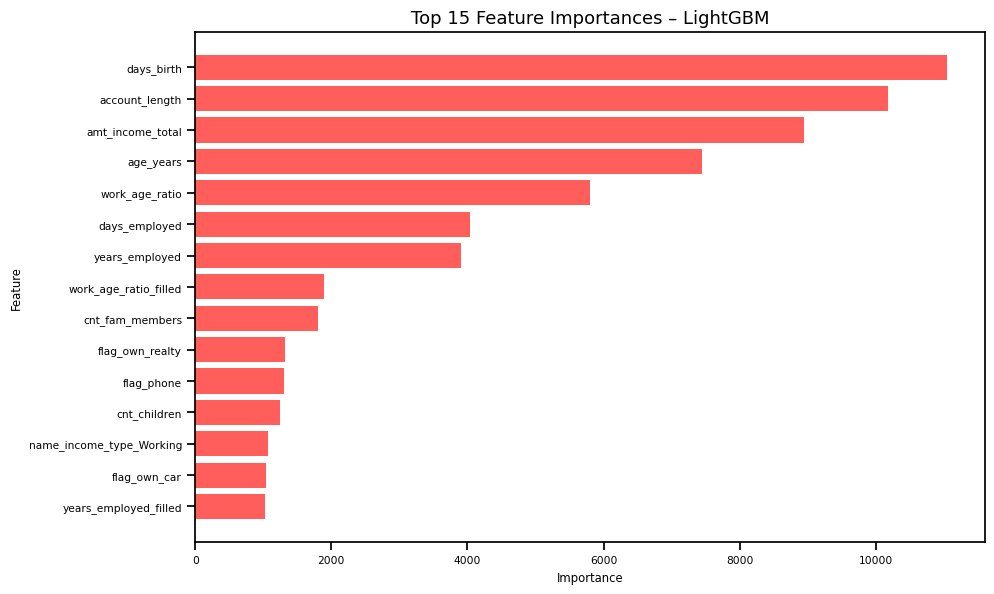


Top 15 important features:
                     Feature  Importance
5                 days_birth       11049
11            account_length       10184
4           amt_income_total        8947
13                 age_years        7453
14            work_age_ratio        5798
6              days_employed        4032
12            years_employed        3911
18     work_age_ratio_filled        1899
10           cnt_fam_members        1797
2            flag_own_realty        1314
8                 flag_phone        1298
3               cnt_children        1241
44  name_income_type_Working        1065
1               flag_own_car        1046
17     years_employed_filled        1019


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

importances = best_lgb.feature_importances_
features = X_train.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'].head(15)[::-1], feat_imp['Importance'].head(15)[::-1])
plt.title('Top 15 Feature Importances – LightGBM')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 15 important features:")
print(feat_imp.head(15))



Default rate by days_birth:
bin
(-25152.001, -20308.0]    0.095362
(-20308.0, -17115.0]      0.119792
(-17115.0, -14379.6]      0.117954
(-14379.6, -11809.2]      0.127216
(-11809.2, -7489.0]       0.147473
Name: y, dtype: float64


/tmp/ipython-input-1313923630.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = temp.groupby('bin')['y'].mean()


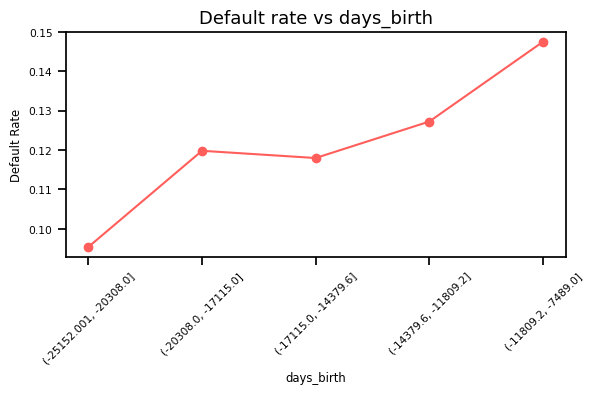


Default rate by account_length:
bin
(-0.001, 11.0]    0.077867
(11.0, 20.0]      0.111748
(20.0, 32.0]      0.132663
(32.0, 44.0]      0.136629
(44.0, 60.0]      0.153473
Name: y, dtype: float64


/tmp/ipython-input-1313923630.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = temp.groupby('bin')['y'].mean()


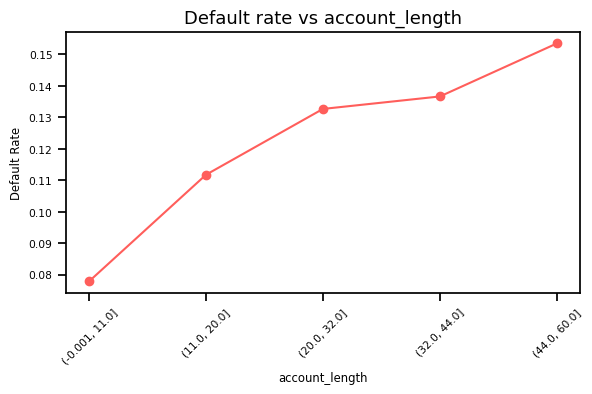

/tmp/ipython-input-1313923630.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = temp.groupby('bin')['y'].mean()



Default rate by amt_income_total:
bin
(26999.999, 112500.0]    0.118752
(112500.0, 135000.0]     0.119344
(135000.0, 180000.0]     0.119662
(180000.0, 225000.0]     0.132783
(225000.0, 393750.0]     0.119828
Name: y, dtype: float64


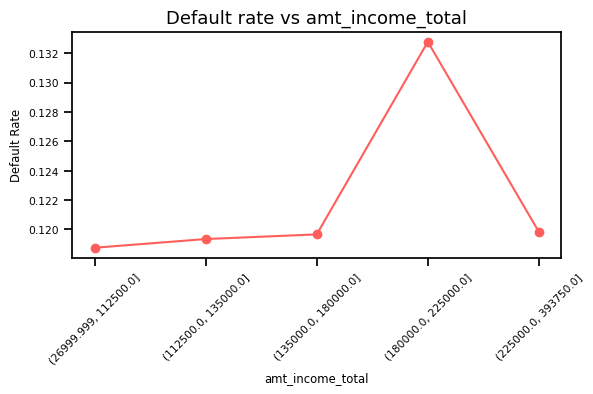

/tmp/ipython-input-1313923630.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = temp.groupby('bin')['y'].mean()



Default rate by age_years:
bin
(20.503, 32.332]    0.147473
(32.332, 39.37]     0.127216
(39.37, 46.859]     0.117770
(46.859, 55.601]    0.119979
(55.601, 68.864]    0.095362
Name: y, dtype: float64


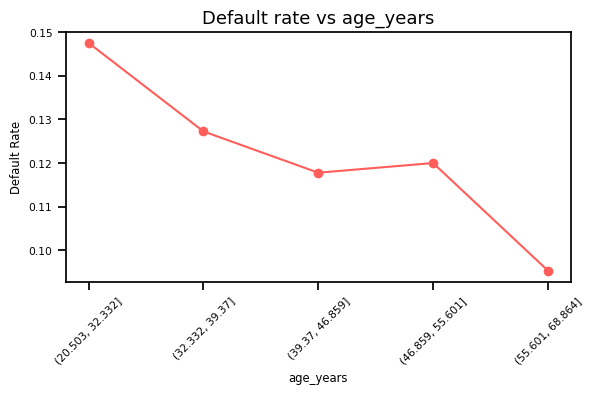

/tmp/ipython-input-1313923630.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = temp.groupby('bin')['y'].mean()



Default rate by work_age_ratio:
bin
(-0.001, 0.0121]    0.102137
(0.0121, 0.0678]    0.123045
(0.0678, 0.135]     0.139729
(0.135, 0.239]      0.126694
(0.239, 0.494]      0.116206
Name: y, dtype: float64


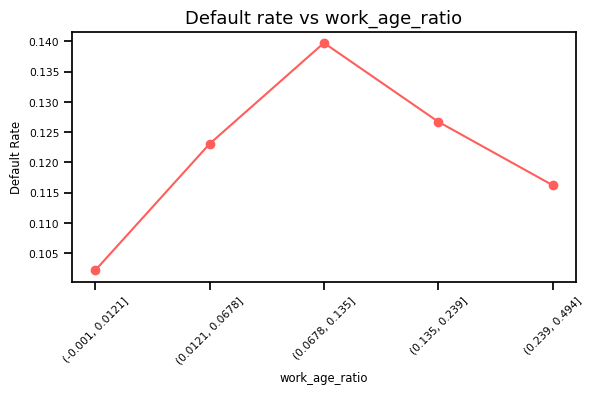

In [ ]:
## Risk Analysis via Binning of the Top 5 Most Important Features
top_features = feat_imp['Feature'].head(5)

for f in top_features:
    temp = pd.DataFrame({'x': X_ready[f], 'y': y_ready})
    temp = temp.dropna()


    temp['bin'] = pd.qcut(temp['x'], 5, duplicates='drop')
    grp = temp.groupby('bin')['y'].mean()

    print(f"\nDefault rate by {f}:")
    print(grp)

    plt.figure(figsize=(6,4))
    plt.plot(grp.index.astype(str), grp.values, marker='o')
    plt.title(f"Default rate vs {f}")
    plt.xlabel(f)
    plt.ylabel('Default Rate')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### **Feature-Level Risk Interpretation**

The default rate represents the proportion of customers labeled as high risk (target = 1) within each feature segment.

Key observations from the analysis include:
1. Customers with higher financial pressure (e.g., lower income levels) exhibit the highest default risk.
2. Younger customers or those with less stable employment profiles show significantly higher risk compared to older or long-tenured working populations.
3. Longer account exposure and longer observed credit histories are associated with a higher probability of being flagged as delinquent, reflecting increased opportunities for missed payments.

Overall, the final feature structure indicates that **financial stability** and **career maturity** are two dominant dimensions influencing credit default risk.


## **Limitations & Next Steps**

Several potential improvements could be explored in future iterations of this project:

- Incorporate time-aware modeling techniques to better capture the sequential nature of credit behavior, rather than relying solely on aggregated historical features.
- Evaluate cost-sensitive learning or explicit loss functions to directly encode asymmetric misclassification costs between false positives and false negatives.
- Explore model explainability techniques (e.g., SHAP values) to improve transparency and support regulatory or business interpretation requirements.
- Validate model stability across different time windows to assess robustness under changing economic conditions.

These extensions would further align the modeling framework with real-world credit risk management practices.
